# Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from astropy.visualization import simple_norm
import photutils
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
from astropy.stats import sigma_clipped_stats, SigmaClip
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from photutils.segmentation import detect_sources
from scipy import stats
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from photutils.detection import DAOStarFinder
from astroquery.gaia import Gaia
import pandas as pd
import subprocess
import shutil
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from pathlib import Path
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from scipy.stats import siegelslopes

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


# Open folders and dark substraction

In [ ]:
base_dir = Path('/mnt/c/Users/catal/Downloads/unistellar_observations_april_6_2026')

GAIN_KEYS = ('GAIN', 'EGAIN', 'CCDGAIN', 'CAMGAIN')
EXPOSURE_KEYS = ('EXPTIME', 'EXPOSURE', 'EXP', 'EXPO')
FRAME_TYPE_KEYS = ('IMAGETYP', 'FRAME', 'OBSTYPE')
FITS_EXTENSIONS = {'.fits', '.fit', '.fts'}


def to_float(value):
    try:
        if value is None:
            return None
        return float(value)
    except (TypeError, ValueError):
        return None


def normalize_gain(value):
    if value is None:
        return None
    return round(float(value), 6)


def extract_first_numeric(header, keys):
    for key in keys:
        value = to_float(header.get(key))
        if value is not None:
            return value
    return None


def infer_frame_type(file_path, header):
    file_lower = file_path.name.lower()
    if 'dark' in file_lower:
        return 'dark'

    for key in FRAME_TYPE_KEYS:
        value = str(header.get(key, '')).lower()
        if 'dark' in value:
            return 'dark'

    return 'science'


def read_frame_info(file_path):
    try:
        header = fits.getheader(file_path)
    except Exception:
        return None

    return {
        'path': file_path,
        'gain': extract_first_numeric(header, GAIN_KEYS),
        'exposure': extract_first_numeric(header, EXPOSURE_KEYS),
        'frame_type': infer_frame_type(file_path, header),
        'date_obs': header.get('DATE-OBS'),
    }


def choose_best_dark(science_frame, dark_candidates):
    if not dark_candidates:
        return None

    science_exposure = science_frame['exposure']
    if science_exposure is not None:
        exp_exact = [
            dark for dark in dark_candidates
            if dark['exposure'] is not None and abs(dark['exposure'] - science_exposure) < 1e-6
        ]
        if exp_exact:
            return exp_exact[0]

        with_exp = [dark for dark in dark_candidates if dark['exposure'] is not None]
        if with_exp:
            return min(with_exp, key=lambda dark: abs(dark['exposure'] - science_exposure))

    return dark_candidates[0]


# ------------------------------------------------------------------
# 1) Scan FITS files and build gain-based dark mapping
# ------------------------------------------------------------------
frames = []
for file_path in sorted(base_dir.rglob('*')):
    if any(part.startswith('.') for part in file_path.parts):
        continue
    if file_path.suffix.lower() not in FITS_EXTENSIONS:
        continue
    info = read_frame_info(file_path)
    if info is not None:
        frames.append(info)

print(f'Total FITS files found: {len(frames)}')

darks = [f for f in frames if f['frame_type'] == 'dark']
sciences = [f for f in frames if f['frame_type'] != 'dark']
print(f'Dark frames: {len(darks)}')
print(f'Science frames: {len(sciences)}')

darks_by_gain = {}
for dark in darks:
    gain_key = normalize_gain(dark['gain'])
    darks_by_gain.setdefault(gain_key, []).append(dark)

matches = []
for sci in sciences:
    gain_key = normalize_gain(sci['gain'])
    dark_candidates = darks_by_gain.get(gain_key, [])
    matched_dark = choose_best_dark(sci, dark_candidates)

    matches.append({
        'science_file': str(sci['path']),
        'science_gain': sci['gain'],
        'science_exposure': sci['exposure'],
        'dark_file': str(matched_dark['path']) if matched_dark else None,
        'dark_gain': matched_dark['gain'] if matched_dark else None,
        'dark_exposure': matched_dark['exposure'] if matched_dark else None,
        'gain_match': matched_dark is not None,
    })

mapping_df = pd.DataFrame(matches)
mapping_csv = base_dir / 'gain_dark_mapping.csv'
mapping_df.to_csv(mapping_csv, index=False)

matched_count = int(mapping_df['gain_match'].sum()) if len(mapping_df) else 0
print(f'Mapping saved: {mapping_csv}')
print(f'Matched: {matched_count}/{len(mapping_df)}')


# ------------------------------------------------------------------
# 2) Apply dark subtraction using matched pairs
# ------------------------------------------------------------------

def subtract_dark_frame(science_file, dark_file, output_dir):
    try:
        with fits.open(dark_file) as hdul_dark:
            dark_data = hdul_dark[0].data.astype(np.float32)

        with fits.open(science_file) as hdul_sci:
            sci_data = hdul_sci[0].data.astype(np.float32)
            sci_header = hdul_sci[0].header

        if dark_data.shape != sci_data.shape:
            return None, False, f'shape mismatch {sci_data.shape} vs {dark_data.shape}'

        corrected_data = np.maximum(sci_data - dark_data, 0)

        output_filename = f"{science_file.stem}_DarkSubtracted.fits"
        output_path = output_dir / output_filename

        hdu = fits.PrimaryHDU(corrected_data.astype(np.uint16), header=sci_header)
        hdu.header['COMMENT'] = f'Dark frame subtracted: {dark_file.name}'
        hdu.writeto(output_path, overwrite=True)

        return output_path, True, None

    except Exception as e:
        return None, False, str(e)


successful = 0
failed = 0

for row in mapping_df.itertuples(index=False):
    if not row.gain_match or pd.isna(row.dark_file):
        failed += 1
        continue

    science_path = Path(row.science_file)
    dark_path = Path(row.dark_file)

    output_dir = science_path.parent / 'dark_subtracted_gain'
    output_dir.mkdir(exist_ok=True)

    output_path, ok, error_msg = subtract_dark_frame(science_path, dark_path, output_dir)
    if ok:
        successful += 1
    else:
        failed += 1
        print(f'Error processing {science_path.name}: {error_msg}')

print('\n' + '=' * 70)
print('GAIN-MATCHED DARK SUBTRACTION SUMMARY')
print('=' * 70)
print(f'Total science frames in mapping: {len(mapping_df)}')
print(f'Successfully dark-subtracted: {successful}')
print(f'Failed or unmatched: {failed}')
print('Output folders: each science folder now has dark_subtracted_gain/')

Total FITS files found: 330
Dark frames: 26
Science frames: 304
Mapping saved: /mnt/c/Users/catal/Downloads/unistellar_observations_april_6_2026/gain_dark_mapping.csv
Matched: 304/304
Error processing 20260407T195445_473_StackSum.fits: shape mismatch (976, 1296) vs (976, 1304)
Error processing 20260407T211147_993_StackSum.fits: shape mismatch (976, 1296) vs (976, 1304)
Error processing 20260407T211444_710_StackSum.fits: shape mismatch (976, 1296) vs (976, 1304)
Error processing 20260407T211625_522_StackSum.fits: shape mismatch (976, 1296) vs (976, 1304)
Error processing 20260407T212312_275_StackSum.fits: shape mismatch (976, 1296) vs (976, 1304)
Error processing 20260407T212639_366_StackSum.fits: shape mismatch (976, 1296) vs (976, 1304)

GAIN-MATCHED DARK SUBTRACTION SUMMARY
Total science frames in mapping: 304
Successfully dark-subtracted: 298
Failed or unmatched: 6
Output folders: each science folder now has dark_subtracted_gain/


# RGB bands separation

In [6]:
# --------------------------------------------------
# Paths
# --------------------------------------------------
observations_folder = r'/mnt/c/Users/catal/Downloads/unistellar_observations_april_6_2026'

# List all observation folders
observation_dirs = [d for d in os.listdir(observations_folder)
                    if os.path.isdir(os.path.join(observations_folder, d))]
observation_dirs.sort()

print(f"Found {len(observation_dirs)} observation folders to process\n")
print("=" * 60)

# --------------------------------------------------
# Initialize counters
# --------------------------------------------------
total_processed = 0
total_errors = 0

# --------------------------------------------------
# Bayer pattern mapping
# Bayer RGGB pattern:
# R: (even row, even col)
# G1: (even row, odd col)
# G2: (odd row, even col)
# B: (odd row, odd col)
# For simplicity, we'll average G1 and G2 for the green channel
# --------------------------------------------------
bayer_channels = {
    "red": lambda data: data[0::2, 0::2],
    "green": lambda data: (data[0::2, 1::2] + data[1::2, 0::2]) / 2.0,
    "blue": lambda data: data[1::2, 1::2]
}

# --------------------------------------------------
# Process each observation folder
# --------------------------------------------------
for obs_idx, obs_dir in enumerate(observation_dirs, 1):
    base_folder = os.path.join(observations_folder, obs_dir)
    dark_subtracted_folder = os.path.join(base_folder, "dark_subtracted_gain")
    
    if not os.path.exists(dark_subtracted_folder):
        print(f"[{obs_idx}/{len(observation_dirs)}] {obs_dir}")
        print(f"  ⚠ 'dark_subtracted_gain' folder not found, skipping...\n")
        continue
    
    print(f"[{obs_idx}/{len(observation_dirs)}] {obs_dir}")
    
    # Find all .fits files in the dark-subtracted folder
    fits_files = [f for f in os.listdir(dark_subtracted_folder) if f.endswith(".fits")]
    print(f"  Found {len(fits_files)} FITS images")
    
    for i, fits_file in enumerate(fits_files, 1):
        file_path = os.path.join(dark_subtracted_folder, fits_file)
        print(f"    [{i}/{len(fits_files)}] {fits_file}...", end=" ")
        
        try:
            # Open FITS file
            with fits.open(file_path) as hdul:
                header = hdul[0].header
                data = hdul[0].data.astype(float)
            
            wcs = WCS(header)
            
            # --------------------------------------------------
            # Process each Bayer channel
            # --------------------------------------------------
            for band_name, extractor in bayer_channels.items():
                band_folder = os.path.join(base_folder, f"{band_name}_band")
                os.makedirs(band_folder, exist_ok=True)
                
                # Extract channel data
                band_data = extractor(data)
                
                # Adjust WCS for reduced image size
                wcs_band = wcs.deepcopy()
                
                if wcs_band.wcs.crpix is not None:
                    wcs_band.wcs.crpix /= 2.0
                
                if wcs_band.wcs.cdelt is not None:
                    wcs_band.wcs.cdelt *= 2.0
                
                # Update header with adjusted WCS
                header.update(wcs_band.to_header())
                
                # Save new FITS file
                base_name = os.path.splitext(fits_file)[0]
                new_filename = os.path.join(band_folder, f"{base_name}_{band_name[0]}_band.fits")
                hdu = fits.PrimaryHDU(band_data, header=header)
                hdu.writeto(new_filename, overwrite=True)
            
            print("✓")
            total_processed += 1
            
        except Exception as e:
            print(f"✗ Error: {str(e)}")
            total_errors += 1
    
    print()

# --------------------------------------------------
# Summary
# --------------------------------------------------
print("=" * 60)
print("Processing completed")
print(f"Total images processed: {total_processed}")
print(f"Total errors: {total_errors}")

Found 32 observation folders to process

[1/32] 20260407T195234_515
  Found 32 FITS images
    [1/32] 20260407T195239_093_StackInput_DarkSubtracted.fits... ✓
    [2/32] 20260407T195243_065_StackInput_DarkSubtracted.fits... ✓
    [3/32] 20260407T195247_037_StackInput_DarkSubtracted.fits... ✓
    [4/32] 20260407T195251_009_StackInput_DarkSubtracted.fits... ✓
    [5/32] 20260407T195254_981_StackInput_DarkSubtracted.fits... ✓
    [6/32] 20260407T195258_952_StackInput_DarkSubtracted.fits... ✓
    [7/32] 20260407T195302_924_StackInput_DarkSubtracted.fits... ✓
    [8/32] 20260407T195306_896_StackInput_DarkSubtracted.fits... ✓
    [9/32] 20260407T195310_868_StackInput_DarkSubtracted.fits... ✓
    [10/32] 20260407T195314_840_StackInput_DarkSubtracted.fits... ✓
    [11/32] 20260407T195318_811_StackInput_DarkSubtracted.fits... ✓
    [12/32] 20260407T195322_783_StackInput_DarkSubtracted.fits... ✓
    [13/32] 20260407T195326_755_StackInput_DarkSubtracted.fits... ✓
    [14/32] 20260407T195330_727_St

# Astrometry.net WCS calculation

In [ ]:
# Base folder containing all observation folders
observations_folder = r"/mnt/c/Users/catal/Downloads/unistellar_observations_april_6_2026"

# Bands to process
bands = ["red", "green", "blue"]

# Root folder to store WCS-solved images
wcs_output_root = os.path.join(observations_folder, "wcs_solved")
os.makedirs(wcs_output_root, exist_ok=True)

# Find solve-field binary
solve_field_bin = shutil.which("solve-field")
if solve_field_bin is None:
    raise FileNotFoundError(
        "solve-field not found in PATH. Install astrometry.net or set full binary path."
    )

# Loop through each observation folder
for obs_dir in sorted(os.listdir(observations_folder)):
    base_folder = os.path.join(observations_folder, obs_dir)
    
    if not os.path.isdir(base_folder) or obs_dir == "wcs_solved":
        continue
    
    print(f"\nProcessing observation: {obs_dir}")
    
    # Loop through each band
    for band in bands:
        band_folder = os.path.join(base_folder, f"{band}_band")
        if not os.path.isdir(band_folder):
            print(f"  ⚠ No folder for {band} band, skipping...")
            continue
        
        output_band_folder = os.path.join(wcs_output_root, obs_dir, f"{band}_band")
        os.makedirs(output_band_folder, exist_ok=True)
        
        fits_files = sorted(
            f for f in os.listdir(band_folder)
            if f.lower().endswith((".fits", ".fit", ".fts"))
        )
        print(f"  {band.capitalize()} band: {len(fits_files)} images found")
        
        for i, fits_file in enumerate(fits_files, 1):
            fits_path = os.path.join(band_folder, fits_file)
            base_name = os.path.splitext(fits_file)[0]
            new_fits_path = os.path.join(output_band_folder, f"{base_name}.new.fits")

            print(f"    [{i}/{len(fits_files)}] Solving {fits_file}...", end=" ")
            cmd = [
                solve_field_bin,
                fits_path,
                "--overwrite",
                "--dir", output_band_folder,
                "--new-fits",
                "--no-plots",
                "--scale-low", "0.5",
                "--scale-high", "5.0",
                "--verbose",
            ]
            
            try:
                proc = subprocess.run(cmd, check=True, text=True, capture_output=True)
                if os.path.exists(new_fits_path):
                    print(f"✓ {os.path.basename(new_fits_path)}")
                else:
                    print("✗ no .new output")
                    print(proc.stdout)
                    print(proc.stderr)
            except subprocess.CalledProcessError as e:
                print(f"✗ Failed returncode={e.returncode}")
                print(e.stdout)
                print(e.stderr)



Processing observation: 20260407T195234_515
  Red band: 32 images found
    [1/32] Solving 20260407T195239_093_StackInput_DarkSubtracted_r_band.fits... ✓
    [2/32] Solving 20260407T195243_065_StackInput_DarkSubtracted_r_band.fits... ✓
    [3/32] Solving 20260407T195247_037_StackInput_DarkSubtracted_r_band.fits... ✓
    [4/32] Solving 20260407T195251_009_StackInput_DarkSubtracted_r_band.fits... ✓
    [5/32] Solving 20260407T195254_981_StackInput_DarkSubtracted_r_band.fits... ✓
    [6/32] Solving 20260407T195258_952_StackInput_DarkSubtracted_r_band.fits... ✓
    [7/32] Solving 20260407T195302_924_StackInput_DarkSubtracted_r_band.fits... ✓
    [8/32] Solving 20260407T195306_896_StackInput_DarkSubtracted_r_band.fits... ✓
    [9/32] Solving 20260407T195310_868_StackInput_DarkSubtracted_r_band.fits... ✓
    [10/32] Solving 20260407T195314_840_StackInput_DarkSubtracted_r_band.fits... ✓
    [11/32] Solving 20260407T195318_811_StackInput_DarkSubtracted_r_band.fits... ✓
    [12/32] Solving 202

KeyboardInterrupt: 

# Centroids and flux with DAOstar finder

In [6]:
# -------------------------------------------------------
# Root WCS folder (for this dataset)
# -------------------------------------------------------
wcs_root = Path("/mnt/c/Users/catal/Downloads/unistellar_observations_april_6_2026/wcs_solved")

if not wcs_root.exists():
    raise FileNotFoundError(
        f"wcs_root does not exist: {wcs_root}\n"
        "Expected root for this run: /mnt/c/Users/catal/Downloads/unistellar_observations_april_6_2026/wcs_solved"
    )

all_sources = []

# -------------------------------------------------------
# Find ALL .new files in ALL subfolders of this root only
# -------------------------------------------------------
all_new_files = sorted(wcs_root.rglob("*.new"))
print(f"Found {len(all_new_files)} solved images in: {wcs_root}\n")

# -------------------------------------------------------
# Loop over every solved image
# -------------------------------------------------------
for file in all_new_files:

    try:
        #print(f"Processing {file.name}")

        with fits.open(file) as hdul:
            header = hdul[0].header
            data = hdul[0].data.astype(np.float32)

        wcs = WCS(header)

        # Determine band from folder name
        if "red_band" in str(file):
            band = "red"
        elif "green_band" in str(file):
            band = "green"
        elif "blue_band" in str(file):
            band = "blue"
        else:
            band = "unknown"

        # -------------------------------------------------------
        # Background statistics
# -------------------------------------------------------
        mean, median, std = sigma_clipped_stats(data, sigma=3.0)

        daofind = DAOStarFinder(fwhm=4.0, threshold=3.0 * std)
        sources = daofind(data - median)

        if sources is None:
            print("  No stars detected")
            continue

        # -------------------------------------------------------
# Aperture photometry
# -------------------------------------------------------
        positions = np.transpose((sources["xcentroid"], sources["ycentroid"]))

        aperture = CircularAperture(positions, r=6)
        annulus = CircularAnnulus(positions, r_in=8, r_out=12)

        aper_stats = aperture_photometry(data, aperture)
        annulus_stats = aperture_photometry(data, annulus)

        bkg_mean = annulus_stats['aperture_sum'] / annulus.area
        bkg_total = bkg_mean * aperture.area

        flux = aper_stats['aperture_sum'] - bkg_total

        # Convert to RA/Dec
        ra, dec = wcs.all_pix2world(
            sources["xcentroid"],
            sources["ycentroid"],
            0
        )

        # Store everything
        for i in range(len(sources)):
            all_sources.append({
                "filename": file.name,
                "band": band,
                "x_centroid": float(sources["xcentroid"][i]),
                "y_centroid": float(sources["ycentroid"][i]),
                "flux": float(flux[i]),
                "ra_deg": float(ra[i]),
                "dec_deg": float(dec[i])
            })

        #print(f"  Detected {len(sources)} stars")

    except Exception as e:
        print(f"Error processing {file.name}: {e}")

# -------------------------------------------------------
# Convert to DataFrame
# -------------------------------------------------------
df_sources = pd.DataFrame(all_sources)

print("\nExtraction complete.")
print(f"Total detected sources: {len(df_sources)}")
#print(df_sources.head())


Found 524 solved images in: /mnt/c/Users/catal/Downloads/unistellar_skyglow_test/wcs_solved


Extraction complete.
Total detected sources: 203573


# Gaia crossmatch

In [ ]:
import time

Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
Gaia.ROW_LIMIT = 10000

wcs_root = Path("/mnt/c/Users/catal/Downloads/unistellar_observations_april_6_2026/wcs_solved")

if not wcs_root.exists():
    raise FileNotFoundError(f"wcs_root does not exist: {wcs_root}")

# Find ALL .new files
all_new_files = sorted(wcs_root.rglob("*.new"))
print(f"Found {len(all_new_files)} WCS-solved images for Gaia crossmatch\n")

matched_sources = []
output_csv = Path("/home/catal/code/pollution/march_4_obs/march_4_gaia_results.csv")
processed_files = 0

Gaia.login(user='cvillega', password='Gaiacata2026*')

try:
    # Loop over each WCS-solved image
    for file in all_new_files:

        # Determine band from folder name
        if "red_band" in str(file):
            band = "red"
        elif "green_band" in str(file):
            band = "green"
        elif "blue_band" in str(file):
            band = "blue"
        else:
            band = "unknown"

        try:
            # Open FITS
            with fits.open(file) as hdul:
                header = hdul[0].header
                data = hdul[0].data.astype(np.float32)

            # Build WCS
            wcs = WCS(header)

            # Background stats
            mean, median, std = sigma_clipped_stats(data, sigma=3.0)
            mode = 3 * median - 2 * mean

            # Detect stars
            daofind = DAOStarFinder(fwhm=3.0, threshold=5.0 * std)
            sources = daofind(data - mode)

            if sources is None:
                print(f"No stars found in {file.name}")
                continue

            x = sources["xcentroid"]
            y = sources["ycentroid"]
            flux = sources["flux"]
            mag_inst = sources["mag"]

            # Convert to RA/Dec
            ra, dec = wcs.all_pix2world(x, y, 0)
            image_coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)

            # Gaia query
            center_coord = SkyCoord(np.mean(ra)*u.deg, np.mean(dec)*u.deg)
            radius = 0.4 * u.deg

            print(f"Querying Gaia for {band}: {file.name}...")

            gaia_table = None
            max_retries = 3
            for attempt in range(1, max_retries + 1):
                try:
                    job = Gaia.cone_search_async(coordinate=center_coord, radius=radius)
                    gaia_table = job.get_results()
                    break
                except Exception as e:
                    if attempt == max_retries:
                        raise
                    wait_s = float(attempt)
                    print(
                        f"Gaia query failed for {band}: {file.name} "
                        f"(attempt {attempt}/{max_retries}): {e}. "
                        f"Retrying in {wait_s:.1f}s..."
                    )
                    time.sleep(wait_s)

            # Archive guidance: space out consecutive heavy queries.
            time.sleep(1.0)

            if len(gaia_table) == 0:
                print(f"No Gaia sources found for {band}: {file.name}")
                continue

            gaia_coords = SkyCoord(ra=gaia_table["ra"], dec=gaia_table["dec"])

            # Cross-match image stars with Gaia
            idx, sep2d, _ = image_coords.match_to_catalog_sky(gaia_coords)
            max_sep = 2.0 * u.arcsec
            good_matches = sep2d < max_sep

            for i, match in enumerate(good_matches):
                if match:
                    gaia_idx = idx[i]
                    matched_sources.append({
                        "filename": file.name,
                        "band": band,
                        "full_path": str(file),
                        "x_centroid": float(x[i]),
                        "y_centroid": float(y[i]),
                        "ra_image": float(ra[i]),
                        "dec_image": float(dec[i]),
                        "flux": float(flux[i]),
                        "mag_inst": float(mag_inst[i]),
                        "ra_gaia": gaia_table["ra"][gaia_idx],
                        "dec_gaia": gaia_table["dec"][gaia_idx],
                        "phot_g_mean_mag": gaia_table["phot_g_mean_mag"][gaia_idx],
                        "phot_bp_mean_mag": gaia_table["phot_bp_mean_mag"][gaia_idx],
                        "phot_rp_mean_mag": gaia_table["phot_rp_mean_mag"][gaia_idx],
                        "separation_arcsec": sep2d[i].arcsec
                    })

            print(f"{band}: {file.name}: {np.sum(good_matches)} matches found")
        processed_files += 1
        if processed_files % 10 == 0:
            pd.DataFrame(matched_sources).to_csv(output_csv, index=False)
            print(f"Saved partial Gaia crossmatch CSV after {processed_files} files: {output_csv}")

        except Exception as e:
            print(f"Error processing {file.name}: {e}")
            continue

finally:
    Gaia.logout()

# Create DataFrame
df_matched = pd.DataFrame(matched_sources)

if len(df_matched) > 0:
    # Map Gaia magnitude to the corresponding instrumental band:
    # red -> phot_rp_mean_mag, green -> phot_g_mean_mag, blue -> phot_bp_mean_mag
    df_matched['phot_band_mag'] = df_matched.apply(
        lambda row: row['phot_rp_mean_mag'] if row['band'] == 'red' 
                   else (row['phot_g_mean_mag'] if row['band'] == 'green' 
                         else row['phot_bp_mean_mag']),
        axis=1
    )

    df_matched.to_csv(output_csv, index=False)
    print(f"\nSaved {len(df_matched)} matched sources to {output_csv}")
else:
    print("No matched sources found.")


Found 524 WCS-solved images for Gaia crossmatch

INFO: Login to gaia TAP server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
Querying Gaia for blue: 20260304T203949_292_Transient_DarkSubtracted_b_band.new...
INFO: Query finished. [astroquery.utils.tap.core]
blue: 20260304T203949_292_Transient_DarkSubtracted_b_band.new: 16 matches found
Querying Gaia for blue: 20260304T203953_262_Transient_DarkSubtracted_b_band.new...
INFO: Query finished. [astroquery.utils.tap.core]
blue: 20260304T203953_262_Transient_DarkSubtracted_b_band.new: 15 matches found
Querying Gaia for green: 20260304T203949_292_Transient_DarkSubtracted_g_band.new...
INFO: Query finished. [astroquery.utils.tap.core]
green: 20260304T203949_292_Transient_DarkSubtracted_g_band.new: 17 matches found
Querying Gaia for green: 20260304T203953_262_Transient_DarkSubtracted_g_band.new...
INFO: Query finished. [astroquery.utils.tap

# Magnitudes plot

In [2]:
output_csv = Path("/home/catal/code/pollution/march_4_obs/march_4_gaia_results.csv")
df_matched = pd.read_csv(output_csv)
df_matched

,filename,band,full_path,x_centroid,y_centroid,ra_image,dec_image,flux,mag_inst,ra_gaia,dec_gaia,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,separation_arcsec,phot_band_mag
0,20260304T203949_292_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/unistellar_skyglo...,18.886272,65.452859,298.177925,68.328317,78336.031250,-12.234903,298.178149,68.328219,11.133067,11.436281,10.669791,0.463020,11.436281
1,20260304T203949_292_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/unistellar_skyglo...,281.183443,76.086527,297.501558,68.338005,67856.031250,-12.078971,297.501626,68.338152,11.405084,11.800053,10.8344755,0.536206,11.800053
2,20260304T203949_292_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/unistellar_skyglo...,68.610659,228.452856,298.050556,68.483971,101248.031250,-12.513467,298.050635,68.483899,10.994287,12.385734,9.83438,0.278023,12.385734
3,20260304T203949_292_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/unistellar_skyglo...,585.421822,251.820757,296.707456,68.501638,191472.031250,-13.205263,296.707345,68.501624,10.122788,10.34618,9.749845,0.154060,10.34618
4,20260304T203949_292_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/unistellar_skyglo...,137.107583,264.764519,297.872489,68.518614,58112.027344,-11.910666,297.873065,68.518772,11.606066,12.358189,10.766496,0.948637,12.358189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13432,20260304T213810_942_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/unistellar_skyglo...,448.499409,309.890519,93.561571,49.259263,1841.593628,-8.162985,93.561401,49.258819,10.612618,11.139104,9.928547,1.648681,9.928547
13433,20260304T213810_942_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/unistellar_skyglo...,264.191888,320.042798,93.667547,49.097611,7217.593750,-9.645981,93.667531,49.097655,8.732652,9.327863,8.000005,0.165068,8.000005
13434,20260304T213810_942_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/unistellar_skyglo...,116.180506,331.799479,93.757129,48.969087,4593.593750,-9.155381,93.757232,48.968736,9.615812,9.629032,9.57168,1.288612,9.57168
13435,20260304T213810_942_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/unistellar_skyglo...,351.439843,367.858288,93.689498,49.191290,2625.593506,-8.548069,93.689583,49.191405,10.067928,10.608746,9.374668,0.459501,9.374668


,band,slope,intercept,r2,n_points_raw,n_points_used
0,blue,0.235897,14.416674,0.118567,4191,3187
1,green,0.238510,14.092220,0.125136,5056,3604
2,red,0.279863,13.883900,0.149924,4166,3127


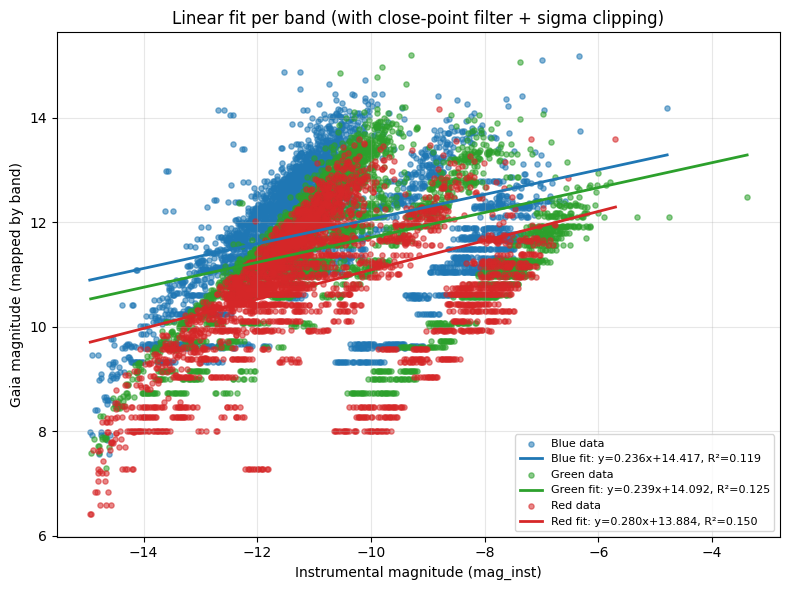

In [3]:
if "df_matched" not in globals():
    raise ValueError("df_matched is not defined. Run the Gaia crossmatch cell first.")

needed = {"band", "mag_inst", "phot_g_mean_mag", "phot_bp_mean_mag", "phot_rp_mean_mag"}
missing = needed - set(df_matched.columns)
if missing:
    raise ValueError(f"df_matched is missing columns: {missing}")


def sigma_clip_line(x, y, sigma=3.0, max_iter=5):
    """Iterative sigma clipping on residuals of a linear fit."""
    if len(x) < 3:
        return x, y

    keep = np.ones(len(x), dtype=bool)
    for _ in range(max_iter):
        if keep.sum() < 3:
            break

        xk = x[keep]
        yk = y[keep]
        slope, intercept = np.polyfit(xk, yk, 1)
        resid = yk - (slope * xk + intercept)

        med = np.median(resid)
        mad = np.median(np.abs(resid - med))
        if mad == 0:
            break

        robust_std = 1.4826 * mad
        local_keep = np.abs(resid - med) <= sigma * robust_std

        new_keep = np.zeros_like(keep)
        new_keep[np.where(keep)[0][local_keep]] = True

        if new_keep.sum() == keep.sum():
            keep = new_keep
            break

        keep = new_keep

    return x[keep], y[keep]


def filter_close_points(x, y, dx=0.02, dy=0.02):
    """Collapse very close points using a 2D grid in (x, y) space."""
    if len(x) == 0:
        return x, y

    qx = np.round(x / dx).astype(int)
    qy = np.round(y / dy).astype(int)

    df_xy = pd.DataFrame({"x": x, "y": y, "qx": qx, "qy": qy})
    grouped = df_xy.groupby(["qx", "qy"], as_index=False)

    x_f = grouped["x"].median()["x"].to_numpy(dtype=float)
    y_f = grouped["y"].median()["y"].to_numpy(dtype=float)
    return x_f, y_f


# 2) Build Gaia magnitude mapped to each instrumental band
tmp = df_matched.copy()
tmp["gaia_mag"] = np.where(
    tmp["band"] == "green", tmp["phot_g_mean_mag"],
    np.where(tmp["band"] == "blue", tmp["phot_bp_mean_mag"], tmp["phot_rp_mean_mag"])
)

# 3) Fit per band
colors = {"blue": "C0", "green": "C2", "red": "C3"}
labels = {"blue": "Blue", "green": "Green", "red": "Red"}
fit_rows = []

plt.figure(figsize=(8, 6))

for b in ["blue", "green", "red"]:
    sub = tmp[tmp["band"] == b].copy()

    x = pd.to_numeric(sub["mag_inst"], errors="coerce").values
    y = pd.to_numeric(sub["gaia_mag"], errors="coerce").values

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    n_raw = len(x)
    if n_raw < 2:
        print(f"{labels[b]} band: not enough valid points.")
        continue

    # Remove very close points before fitting
    x, y = filter_close_points(x, y, dx=0.02, dy=0.02)

    # Sigma-clip outliers around iterative linear fit
    x, y = sigma_clip_line(x, y, sigma=3.0, max_iter=5)

    if len(x) < 2:
        print(f"{labels[b]} band: not enough points after filtering/clipping.")
        continue

    slope, intercept = np.polyfit(x, y, 1)
    yhat = slope * x + intercept

    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

    fit_rows.append({
        "band": b,
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "n_points_raw": n_raw,
        "n_points_used": len(x)
    })

    # plot points + fitted line
    plt.scatter(x, y, s=14, alpha=0.55, color=colors[b], label=f"{labels[b]} data")
    xx = np.linspace(x.min(), x.max(), 100)
    yy = slope * xx + intercept
    plt.plot(xx, yy, color=colors[b], lw=2,
             label=f"{labels[b]} fit: y={slope:.3f}x+{intercept:.3f}, R²={r2:.3f}")

# 4) Output
fit_df = pd.DataFrame(fit_rows)
if not fit_df.empty:
    display(fit_df.sort_values("band"))
else:
    print("No bands had enough valid points to fit.")

plt.xlabel("Instrumental magnitude (mag_inst)")
plt.ylabel("Gaia magnitude (mapped by band)")
plt.title("Linear fit per band (with close-point filter + sigma clipping)")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# Airmass calculation

In [7]:
# Fast airmass/delta_m computation using full_path + header cache
if "df_matched" not in globals() or df_matched.empty:
    raise RuntimeError("df_matched is missing or empty. Run the Gaia crossmatch cell first.")

# Initialize columns if missing
if "airmass" not in df_matched.columns:
    df_matched["airmass"] = np.nan
if "delta_m" not in df_matched.columns:
    df_matched["delta_m"] = np.nan

# Keep only rows with resolvable file path
valid_path_mask = df_matched["full_path"].astype(str).str.len() > 0
if not valid_path_mask.any():
    raise RuntimeError("No valid full_path values in df_matched.")

meta_cache = {}

def read_image_meta(file_path):
    if file_path in meta_cache:
        return meta_cache[file_path]
    try:
        with fits.open(file_path) as hdul:
            header = hdul[0].header
        date_obs = header.get("DATE-OBS")
        lon_val = header.get("LONGITUD", header.get("LONGITUDE", 0))
        lat_val = header.get("LATITUDE", 0)
        alt_val = header.get("ALTITUDE", 0)
        if date_obs is None:
            meta_cache[file_path] = None
            return None
        obs_time = Time(date_obs, format="isot", scale="utc")
        location = EarthLocation(lat=lat_val * u.deg, lon=lon_val * u.deg, height=alt_val * u.m)
        meta_cache[file_path] = (obs_time, location)
        return meta_cache[file_path]
    except Exception:
        meta_cache[file_path] = None
        return None

unique_paths = df_matched.loc[valid_path_mask, "full_path"].unique()
print(f"Computing airmass for {len(unique_paths)} images")

for idx, file_path in enumerate(unique_paths, start=1):
    meta = read_image_meta(file_path)
    if meta is None:
        continue

    obs_time, location = meta
    path_mask = df_matched["full_path"] == file_path
    image_data = df_matched.loc[path_mask]

    coords = SkyCoord(
        ra=image_data["ra_image"].to_numpy(dtype=float) * u.deg,
        dec=image_data["dec_image"].to_numpy(dtype=float) * u.deg,
    )

    altaz = coords.transform_to(AltAz(obstime=obs_time, location=location))
    zenith = (90 * u.deg) - altaz.alt
    X = (1.0 / np.cos(zenith.to(u.rad))).value

    valid_airmass = np.isfinite(X)# & (X > 1) #& (X < 5)
    if not np.any(valid_airmass):
        continue

    valid_idx = image_data.index[valid_airmass]
    df_matched.loc[valid_idx, "airmass"] = X[valid_airmass]

    # Coerce strings like '--' to NaN before computing delta_m
    mag_inst_vals = pd.to_numeric(image_data.loc[valid_idx, "mag_inst"], errors="coerce").to_numpy(dtype=float)
    phot_band_vals = pd.to_numeric(image_data.loc[valid_idx, "phot_band_mag"], errors="coerce").to_numpy(dtype=float)
    valid_mag = np.isfinite(mag_inst_vals) & np.isfinite(phot_band_vals)

    if np.any(valid_mag):
        valid_mag_idx = valid_idx[valid_mag]
        df_matched.loc[valid_mag_idx, "delta_m"] = -mag_inst_vals[valid_mag] + phot_band_vals[valid_mag]

    if idx % 25 == 0 or idx == len(unique_paths):
        done_airmass = int(np.isfinite(df_matched["airmass"]).sum())
        done_delta = int(np.isfinite(df_matched["delta_m"]).sum())
        print(f"[{idx}/{len(unique_paths)}] assigned airmass rows: {done_airmass}, delta_m rows: {done_delta}")

airmass = df_matched["airmass"].dropna().to_numpy(dtype=float)
delta_m = df_matched["delta_m"].dropna().to_numpy(dtype=float)

airmass_by_band = {}
delta_m_by_band = {}
for b in ["blue", "green", "red"]:
    band_mask = df_matched["band"] == b
    airmass_by_band[b] = df_matched.loc[band_mask, "airmass"].dropna().to_numpy(dtype=float)
    delta_m_by_band[b] = df_matched.loc[band_mask, "delta_m"].dropna().to_numpy(dtype=float)

print("Total stars used:", len(airmass))
for b in ["blue", "green", "red"]:
    print(f"{b} band: {len(airmass_by_band[b])} valid stars")


Computing airmass for 524 images
[25/524] assigned airmass rows: 480, delta_m rows: 478
[50/524] assigned airmass rows: 1018, delta_m rows: 1016
[75/524] assigned airmass rows: 1550, delta_m rows: 1548
[100/524] assigned airmass rows: 2254, delta_m rows: 2248
[125/524] assigned airmass rows: 2783, delta_m rows: 2776
[150/524] assigned airmass rows: 4210, delta_m rows: 4194
[175/524] assigned airmass rows: 5232, delta_m rows: 5214
[200/524] assigned airmass rows: 6186, delta_m rows: 6164
[225/524] assigned airmass rows: 6754, delta_m rows: 6732
[250/524] assigned airmass rows: 7315, delta_m rows: 7293
[275/524] assigned airmass rows: 8158, delta_m rows: 8136
[300/524] assigned airmass rows: 8716, delta_m rows: 8692
[325/524] assigned airmass rows: 9320, delta_m rows: 9296
[350/524] assigned airmass rows: 9850, delta_m rows: 9826
[375/524] assigned airmass rows: 10387, delta_m rows: 10363
[400/524] assigned airmass rows: 11006, delta_m rows: 10982
[425/524] assigned airmass rows: 11602, 

# Theory implementation

In [8]:
stats_csv = Path("/home/catal/code/pollution/march_4_obs/stats_march_4.csv")
stats_march_4 = pd.read_csv(stats_csv)
stats_march_4

,filename,band,gain,exp_time,bg_mean,bg_median,bg_std,bg_mode,masked_frac
0,20260304T203949_292_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,10238.633789,10224.0,862.404480,10194.732422,0.080911
1,20260304T203953_262_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,10241.283203,10224.0,860.029114,10189.433594,0.086917
2,20260304T203949_292_Transient_DarkSubtracted_g...,green,0.230365,3.969997,7987.897461,7984.0,560.145691,7976.205078,0.110583
3,20260304T203953_262_Transient_DarkSubtracted_g...,green,0.230365,3.969997,7989.201172,7984.0,560.150024,7973.597656,0.116423
4,20260304T203949_292_Transient_DarkSubtracted_r...,red,0.230365,3.969997,10223.581055,10224.0,858.746765,10224.837891,0.085076
...,...,...,...,...,...,...,...,...,...
519,20260304T213809_342_Transient_DarkSubtracted_r...,red,2.363814,0.400000,34.935322,32.0,21.442856,26.129356,0.184847
520,20260304T213809_742_Transient_DarkSubtracted_r...,red,2.363814,0.400000,35.136318,32.0,21.437202,25.727364,0.157639
521,20260304T213810_142_Transient_DarkSubtracted_r...,red,2.363814,0.400000,34.974117,32.0,21.440935,26.051765,0.178360
522,20260304T213810_542_Transient_DarkSubtracted_r...,red,2.363814,0.400000,35.015217,32.0,21.383888,25.969566,0.144077


In [9]:
# Build paired arrays from the same rows to avoid shape mismatches
if "df_matched" not in globals() or df_matched.empty:
    raise RuntimeError("df_matched is missing or empty. Run the Gaia crossmatch cell first.")

if "stats_march_4" not in globals() or stats_march_4.empty:
    raise RuntimeError("stats_march_4 is missing or empty. Run the background stats cell first.")

required_cols = {"airmass", "delta_m"}
missing_cols = required_cols - set(df_matched.columns)
if missing_cols:
    raise RuntimeError(f"df_matched is missing required columns: {missing_cols}")

# Merge df_matched with stats_march_4 to get gain and exp_time
df_with_meta = df_matched.copy()
stats_for_merge = stats_march_4[["filename", "band", "gain", "exp_time"]].copy()
df_with_meta = df_with_meta.merge(
    stats_for_merge, 
    left_on=["filename", "band"], 
    right_on=["filename", "band"], 
    how="left"
)

# Find the most common gain and exp_time combination
df_with_meta["gain_num"] = pd.to_numeric(df_with_meta["gain"], errors="coerce")
df_with_meta["exp_num"] = pd.to_numeric(df_with_meta["exp_time"], errors="coerce")
df_valid = df_with_meta.dropna(subset=["gain_num", "exp_num"])

if df_valid.empty:
    raise RuntimeError("No valid gain/exp_time combinations found after merging with stats_march_4")

# Get the most common combination
combo_counts = df_valid.groupby(["gain_num", "exp_num"]).size().reset_index(name="count")
combo_counts = combo_counts.sort_values("count", ascending=False)

most_common_gain = combo_counts.iloc[0]["gain_num"]
most_common_exp = combo_counts.iloc[0]["exp_num"]
most_common_count = combo_counts.iloc[0]["count"]

print(f"Most common gain: {most_common_gain}, exp_time: {most_common_exp}, count: {most_common_count}")
print("\nAll gain/exp_time combinations found:")
print(combo_counts)

# Filter to only rows with the most common gain and exp_time
filtered = df_with_meta[
    (df_with_meta["gain_num"] == most_common_gain) & 
    (df_with_meta["exp_num"] == most_common_exp)
].copy()

print(f"\nFiltered to {len(filtered)} stars using gain={most_common_gain}, exp_time={most_common_exp}")

paired = filtered[["airmass", "delta_m"]].copy()
paired["airmass"] = pd.to_numeric(paired["airmass"], errors="coerce")
paired["delta_m"] = pd.to_numeric(paired["delta_m"], errors="coerce")
paired = paired.dropna(subset=["airmass", "delta_m"])

airmass = paired["airmass"].to_numpy(dtype=float)
delta_m = paired["delta_m"].to_numpy(dtype=float)

if len(airmass) < 2:
    print("Not enough valid paired points for fitting")
    k, zp = np.nan, np.nan
else:
    # 3-sigma clipping on delta_m
    mean = np.mean(delta_m)
    std = np.std(delta_m)
    clip = np.abs(delta_m - mean) < 3 * std

    airmass = airmass[clip]
    delta_m = delta_m[clip]

    if len(airmass) < 2:
        print("Not enough points after clipping for fitting")
        k, zp = np.nan, np.nan
    else:
        k, zp = np.polyfit(airmass, delta_m, 1)
        print(f"Fit: k={k:.4f}, zp={zp:.4f}, n={len(airmass)}")


Most common gain: 0.2303646, exp_time: 3.969997, count: 5410.0

All gain/exp_time combinations found:
   gain_num   exp_num  count
2  0.230365  3.969997   5410
1  0.071915  0.400000   1831
0  0.040181  0.400000   1742
4  1.483794  0.400000   1580
6  2.363814  0.400000   1580
3  0.931396  1.999998    692
5  1.483794  3.969997    602

Filtered to 5410 stars using gain=0.2303646, exp_time=3.969997
Fit: k=-0.2562, zp=23.8043, n=5343


# Extinction plot

Plotting extinction for 5410 stars with gain ≈ 0.230365
Filtered gain values: [0.230365]
Blue band: slope (extinction coeff) k = -0.26 ± 0.04, intercept (zero point) zp = 24.39 ± 0.05, n = 756
Green band: slope (extinction coeff) k = -0.28 ± 0.03, intercept (zero point) zp = 23.73 ± 0.04, n = 698
Red band: slope (extinction coeff) k = -0.26 ± 0.04, intercept (zero point) zp = 23.32 ± 0.05, n = 746


/tmp/ipykernel_1219/3850390192.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.DataFrame({'airmass': a, 'delta_m': d}).groupby(binned)
/tmp/ipykernel_1219/3850390192.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.DataFrame({'airmass': a, 'delta_m': d}).groupby(binned)
/tmp/ipykernel_1219/3850390192.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.DataFrame({'airmass':

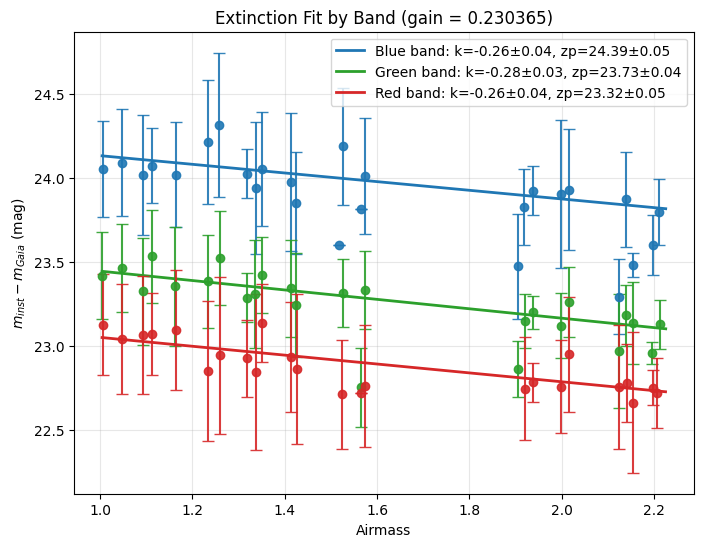

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

colors = {'blue': 'C0', 'green': 'C2', 'red': 'C3'}


def sigma_clip_series(x, y, sigma=3.0):
    if len(x) < 3:
        return x, y
    med = np.median(y)
    mad = np.median(np.abs(y - med))
    if mad == 0:
        return x, y
    robust_std = 1.4826 * mad
    keep = np.abs(y - med) <= sigma * robust_std
    return x[keep], y[keep]


def filter_close_points(x, y, dx=0.02, dy=0.02):
    if len(x) == 0:
        return x, y
    qx = np.round(x / dx).astype(int)
    qy = np.round(y / dy).astype(int)
    df_xy = pd.DataFrame({'x': x, 'y': y, 'qx': qx, 'qy': qy})
    grouped = df_xy.groupby(['qx', 'qy'], as_index=False)
    x_f = grouped['x'].median()['x'].to_numpy(dtype=float)
    y_f = grouped['y'].median()['y'].to_numpy(dtype=float)
    return x_f, y_f


if "df_matched" not in globals() or df_matched.empty:
    raise RuntimeError("df_matched is missing or empty. Run the Gaia crossmatch and airmass cells first.")

if "stats_march_4" not in globals() or stats_march_4.empty:
    raise RuntimeError("stats_march_4 is missing or empty. Run the background stats cell first.")

required_cols = {"band", "airmass", "delta_m"}
missing_cols = required_cols - set(df_matched.columns)
if missing_cols:
    raise RuntimeError(f"df_matched is missing required columns: {missing_cols}")

# Merge df_matched with stats_march_4 to get gain, then filter by gain = 0.230365
df_with_gain = df_matched.copy()
stats_gain = stats_march_4[["filename", "band", "gain"]].copy()
df_with_gain = df_with_gain.merge(stats_gain, left_on=["filename", "band"], right_on=["filename", "band"], how="left")

# Convert gain to numeric and filter using a tolerance for float representation
TARGET_GAIN = 0.230365
df_with_gain["gain_num"] = pd.to_numeric(df_with_gain["gain"], errors="coerce")
df_filtered = df_with_gain[np.isclose(df_with_gain["gain_num"], TARGET_GAIN, atol=1e-6)].copy()

if df_filtered.empty:
    available = df_with_gain["gain_num"].dropna().round(6).unique()
    raise RuntimeError(f"No data found with gain = {TARGET_GAIN}. Available rounded gains: {available}")

print(f"Plotting extinction for {len(df_filtered)} stars with gain ≈ {TARGET_GAIN}")
print("Filtered gain values:", np.unique(np.round(df_filtered["gain_num"], 6)))

n_bins = 50
for b, label in [('blue', 'Blue band'), ('green', 'Green band'), ('red', 'Red band')]:
    band_df = df_filtered.loc[df_filtered['band'] == b, ['airmass', 'delta_m']].copy()
    band_df['airmass'] = pd.to_numeric(band_df['airmass'], errors='coerce')
    band_df['delta_m'] = pd.to_numeric(band_df['delta_m'], errors='coerce')
    band_df = band_df.dropna(subset=['airmass', 'delta_m'])

    if band_df.empty:
        continue

    a = band_df['airmass'].to_numpy(dtype=float)
    d = band_df['delta_m'].to_numpy(dtype=float)

    # Remove very close points and sigma-clip outliers
    a, d = filter_close_points(a, d, dx=0.02, dy=0.02)
    a, d = sigma_clip_series(a, d, sigma=3.0)
    if len(a) < 2:
        continue

    # Determine reasonable bin count
    bins_local = min(n_bins, max(2, len(a)))

    # Bin and compute mean/std
    binned = pd.cut(a, bins=bins_local)
    grouped = pd.DataFrame({'airmass': a, 'delta_m': d}).groupby(binned)
    bin_centers = grouped['airmass'].apply(np.mean)
    bin_means = grouped['delta_m'].apply(np.mean)
    bin_stds = grouped['delta_m'].apply(np.std)

    # Plot binned points with error bars
    plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o', markersize=6,
                 capsize=4, color=colors[b], alpha=0.9)

    # Matplotlib linear regression with uncertainties
    if len(a) >= 2:
        coeffs, cov = np.polyfit(a, d, 1, cov=True)
        slope, intercept = coeffs
        slope_err = np.sqrt(cov[0, 0])
        intercept_err = np.sqrt(cov[1, 1])
        
        x_fit = np.linspace(np.min(a), np.max(a), 100)
        y_fit = slope * x_fit + intercept
        plt.plot(x_fit, y_fit, color=colors[b], linewidth=2, 
                label=f"{label}: k={slope:.2f}±{slope_err:.2f}, zp={intercept:.2f}±{intercept_err:.2f}")
        
        # Print regression values with uncertainties
        print(f"{label}: slope (extinction coeff) k = {slope:.2f} ± {slope_err:.2f}, intercept (zero point) zp = {intercept:.2f} ± {intercept_err:.2f}, n = {len(a)}")
    else:
        plt.plot([], [], color=colors[b], linewidth=2, label=f"{label}: insufficient data")


plt.xlabel("Airmass")
plt.ylabel("$m_{inst} - m_{Gaia}$ (mag)")
plt.title("Extinction Fit by Band (gain = 0.230365)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


Plotting extinction for 1831 stars with gain ≈ 0.071915
Filtered gain values: [0.071915]
Blue band: slope (extinction coeff) k = 40.99 ± 73.74, intercept (zero point) zp = -22.46 ± 81.55, n = 68
Green band: slope (extinction coeff) k = 257.72 ± 62.48, intercept (zero point) zp = -262.74 ± 69.09, n = 54
Red band: slope (extinction coeff) k = 75.55 ± 71.71, intercept (zero point) zp = -61.59 ± 79.31, n = 69


/tmp/ipykernel_1219/3638815485.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.DataFrame({'airmass': a, 'delta_m': d}).groupby(binned)
/tmp/ipykernel_1219/3638815485.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.DataFrame({'airmass': a, 'delta_m': d}).groupby(binned)
/tmp/ipykernel_1219/3638815485.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.DataFrame({'airmass':

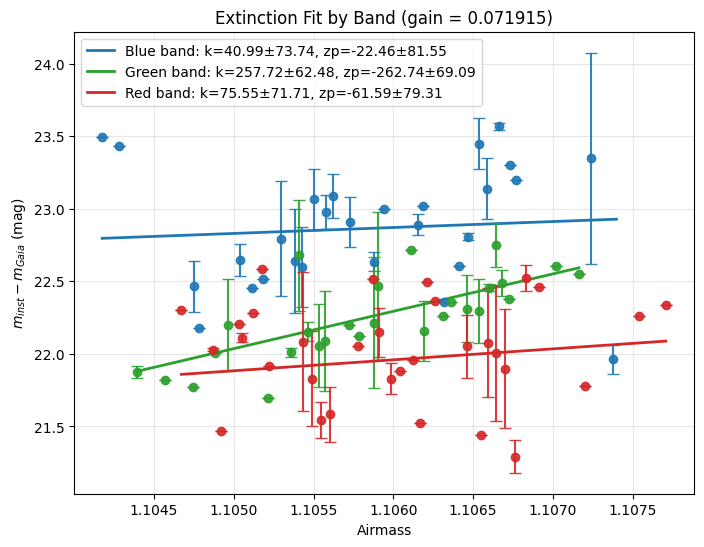

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

colors = {'blue': 'C0', 'green': 'C2', 'red': 'C3'}


def sigma_clip_series(x, y, sigma=3.0):
    if len(x) < 3:
        return x, y
    med = np.median(y)
    mad = np.median(np.abs(y - med))
    if mad == 0:
        return x, y
    robust_std = 1.4826 * mad
    keep = np.abs(y - med) <= sigma * robust_std
    return x[keep], y[keep]


def filter_close_points(x, y, dx=0.02, dy=0.02):
    if len(x) == 0:
        return x, y
    qx = np.round(x / dx).astype(int)
    qy = np.round(y / dy).astype(int)
    df_xy = pd.DataFrame({'x': x, 'y': y, 'qx': qx, 'qy': qy})
    grouped = df_xy.groupby(['qx', 'qy'], as_index=False)
    x_f = grouped['x'].median()['x'].to_numpy(dtype=float)
    y_f = grouped['y'].median()['y'].to_numpy(dtype=float)
    return x_f, y_f


if "df_matched" not in globals() or df_matched.empty:
    raise RuntimeError("df_matched is missing or empty. Run the Gaia crossmatch and airmass cells first.")

if "stats_march_4" not in globals() or stats_march_4.empty:
    raise RuntimeError("stats_march_4 is missing or empty. Run the background stats cell first.")

required_cols = {"band", "airmass", "delta_m"}
missing_cols = required_cols - set(df_matched.columns)
if missing_cols:
    raise RuntimeError(f"df_matched is missing required columns: {missing_cols}")

# Merge df_matched with stats_march_4 to get gain, then filter by gain = 0.071
df_with_gain = df_matched.copy()
stats_gain = stats_march_4[["filename", "band", "gain"]].copy()
df_with_gain = df_with_gain.merge(stats_gain, left_on=["filename", "band"], right_on=["filename", "band"], how="left")

# Convert gain to numeric and filter using a tolerance for float representation
TARGET_GAIN = 0.071915
df_with_gain["gain_num"] = pd.to_numeric(df_with_gain["gain"], errors="coerce")
df_filtered = df_with_gain[np.isclose(df_with_gain["gain_num"], TARGET_GAIN, atol=1e-6)].copy()

if df_filtered.empty:
    available = df_with_gain["gain_num"].dropna().round(6).unique()
    raise RuntimeError(f"No data found with gain = {TARGET_GAIN}. Available rounded gains: {available}")

print(f"Plotting extinction for {len(df_filtered)} stars with gain ≈ {TARGET_GAIN}")
print("Filtered gain values:", np.unique(np.round(df_filtered["gain_num"], 6)))

n_bins = 50
for b, label in [('blue', 'Blue band'), ('green', 'Green band'), ('red', 'Red band')]:
    band_df = df_filtered.loc[df_filtered['band'] == b, ['airmass', 'delta_m']].copy()
    band_df['airmass'] = pd.to_numeric(band_df['airmass'], errors='coerce')
    band_df['delta_m'] = pd.to_numeric(band_df['delta_m'], errors='coerce')
    band_df = band_df.dropna(subset=['airmass', 'delta_m'])

    if band_df.empty:
        continue

    a = band_df['airmass'].to_numpy(dtype=float)
    d = band_df['delta_m'].to_numpy(dtype=float)

    # Remove very close points and sigma-clip outliers
    a, d = filter_close_points(a, d, dx=0.02, dy=0.02)
    a, d = sigma_clip_series(a, d, sigma=3.0)
    if len(a) < 2:
        continue

    # Determine reasonable bin count
    bins_local = min(n_bins, max(2, len(a)))

    # Bin and compute mean/std
    binned = pd.cut(a, bins=bins_local)
    grouped = pd.DataFrame({'airmass': a, 'delta_m': d}).groupby(binned)
    bin_centers = grouped['airmass'].apply(np.mean)
    bin_means = grouped['delta_m'].apply(np.mean)
    bin_stds = grouped['delta_m'].apply(np.std)

    # Plot binned points with error bars
    plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o', markersize=6,
                 capsize=4, color=colors[b], alpha=0.9)

    # Matplotlib linear regression with uncertainties
    if len(a) >= 2:
        coeffs, cov = np.polyfit(a, d, 1, cov=True)
        slope, intercept = coeffs
        slope_err = np.sqrt(cov[0, 0])
        intercept_err = np.sqrt(cov[1, 1])
        
        x_fit = np.linspace(np.min(a), np.max(a), 100)
        y_fit = slope * x_fit + intercept
        plt.plot(x_fit, y_fit, color=colors[b], linewidth=2, 
                label=f"{label}: k={slope:.2f}±{slope_err:.2f}, zp={intercept:.2f}±{intercept_err:.2f}")
        
        # Print regression values with uncertainties
        print(f"{label}: slope (extinction coeff) k = {slope:.2f} ± {slope_err:.2f}, intercept (zero point) zp = {intercept:.2f} ± {intercept_err:.2f}, n = {len(a)}")
    else:
        plt.plot([], [], color=colors[b], linewidth=2, label=f"{label}: insufficient data")


plt.xlabel("Airmass")
plt.ylabel("$m_{inst} - m_{Gaia}$ (mag)")
plt.title("Extinction Fit by Band (gain = 0.071915)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Sky brightness magnitude calculation

In [33]:
mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(488, 652))

In [31]:
# Build local background statistics table for this notebook: stats_march_4
wcs_root_march4 = Path('/mnt/c/Users/catal/Downloads/unistellar_observations_april_6_2026/wcs_solved')
if not wcs_root_march4.exists():
    raise FileNotFoundError(f"WCS folder not found: {wcs_root_march4}")

sigma_clip_bg = SigmaClip(sigma=3.0, maxiters=10)
rows = []
gain_keys = ('GAIN', 'EGAIN', 'CCDGAIN', 'CAMGAIN')
exp_keys = ('EXPTIME', 'EXPOSURE', 'EXP', 'EXPO')

all_new_files = sorted(wcs_root_march4.rglob('*.new'))
print(f"Found {len(all_new_files)} solved images for background stats")

for file in all_new_files:
    try:
        with fits.open(file) as hdul:
            header = hdul[0].header
            data = hdul[0].data.astype(np.float32)
    except Exception as e:
        print(f"Error reading {file.name}: {e}")
        continue

    # Determine band from path
    file_s = str(file)
    if 'red_band' in file_s:
        band = 'red'
    elif 'green_band' in file_s:
        band = 'green'
    elif 'blue_band' in file_s:
        band = 'blue'
    else:
        band = 'unknown'

    gain_value = None
    for k in gain_keys:
        v = header.get(k)
        if v is not None:
            try:
                gain_value = float(v)
                break
            except (TypeError, ValueError):
                pass

    exp_time = None
    for k in exp_keys:
        v = header.get(k)
        if v is not None:
            try:
                exp_time = float(v)
                break
            except (TypeError, ValueError):
                pass

    # Build source mask for robust background measurement
    threshold = detect_threshold(data, nsigma=2.0, sigma_clip=sigma_clip_bg)
    segment_img = detect_sources(data, threshold, npixels=5)

    if segment_img is None:
        mask = np.zeros_like(data, dtype=bool)
    else:
        footprint = circular_footprint(radius=15)
        mask = segment_img.make_source_mask(footprint=footprint)

    mean, median, std = sigma_clipped_stats(data, sigma=3.0, mask=mask)
    mode = 3.0 * median - 2.0 * mean
    masked_frac = float(np.count_nonzero(mask)) / mask.size

    rows.append({
        'filename': file.name,
        'band': band,
        'gain': gain_value,
        'exp_time': exp_time,
        'bg_mean': float(mean),
        'bg_median': float(median),
        'bg_std': float(std),
        'bg_mode': float(mode),
        'masked_frac': masked_frac,
    })

stats_march_4 = pd.DataFrame(rows)
stats_march_4.to_csv('stats_march_4.csv', index=False)

print(f"Saved stats_march_4.csv with {len(stats_march_4)} rows")
display(stats_march_4.head(10))

Found 524 solved images for background stats
Saved stats_march_4.csv with 524 rows


,filename,band,gain,exp_time,bg_mean,bg_median,bg_std,bg_mode,masked_frac
0,20260304T203949_292_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,10238.633789,10224.0,862.404480,10194.732422,0.080911
1,20260304T203953_262_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,10241.283203,10224.0,860.029114,10189.433594,0.086917
2,20260304T203949_292_Transient_DarkSubtracted_g...,green,0.230365,3.969997,7987.897461,7984.0,560.145691,7976.205078,0.110583
3,20260304T203953_262_Transient_DarkSubtracted_g...,green,0.230365,3.969997,7989.201172,7984.0,560.150024,7973.597656,0.116423
4,20260304T203949_292_Transient_DarkSubtracted_r...,red,0.230365,3.969997,10223.581055,10224.0,858.746765,10224.837891,0.085076
5,20260304T203953_262_Transient_DarkSubtracted_r...,red,0.230365,3.969997,10227.724609,10224.0,859.594727,10216.550781,0.087634
6,20260304T204121_618_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,9124.999023,9120.0,812.283264,9110.001953,0.028151
7,20260304T204125_588_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,9136.874023,9136.0,809.187561,9134.251953,0.062868
8,20260304T204121_618_Transient_DarkSubtracted_g...,green,0.230365,3.969997,6446.253418,6448.0,495.070862,6451.493164,0.042602
9,20260304T204125_588_Transient_DarkSubtracted_g...,green,0.230365,3.969997,6461.620605,6456.0,494.736450,6444.758789,0.055325


In [39]:
# Sky magnitude from background using fitted zero point (zp)
# Priority: stats_march_4 (in memory) -> stats_march_4.csv -> all_bands_background_stats.csv

if "zp" not in globals() or not np.isfinite(zp):
    raise RuntimeError("zp is missing or invalid. Run the zero-point fit cell first.")

if "stats_march_4" in globals() and isinstance(stats_march_4, pd.DataFrame) and not stats_march_4.empty:
    bg_df = stats_march_4.copy()
elif Path("stats_march_4.csv").exists():
    bg_df = pd.read_csv("stats_march_4.csv")
elif Path("all_bands_background_stats.csv").exists():
    bg_df = pd.read_csv("all_bands_background_stats.csv")
else:
    raise FileNotFoundError(
        "No background stats found. Run the stats_march_4 cell first to generate stats_march_4.csv"
    )

required = {"filename", "band", "bg_median", "bg_std"}
missing = required - set(bg_df.columns)
if missing:
    raise RuntimeError(f"Background table is missing columns: {missing}")

bg_df["bg_median"] = pd.to_numeric(bg_df["bg_median"], errors="coerce")
bg_df["bg_std"] = pd.to_numeric(bg_df["bg_std"], errors="coerce")
if "gain" in bg_df.columns:
    bg_df["gain"] = pd.to_numeric(bg_df["gain"], errors="coerce")
if "exp_time" in bg_df.columns:
    bg_df["exp_time"] = pd.to_numeric(bg_df["exp_time"], errors="coerce")

# Keep only valid positive-background rows
bg_df = bg_df.dropna(subset=["bg_median", "bg_std"])
bg_df = bg_df[bg_df["bg_median"] > 0].copy()

if bg_df.empty:
    raise RuntimeError("No valid rows left to compute sky magnitude.")

# Check that gain and exp_time are available
if "gain" not in bg_df.columns or "exp_time" not in bg_df.columns:
    raise RuntimeError("gain and exp_time columns are required for flux calculation")

# Flux from your calibration factor, corrected for gain and exposure time
flux = (bg_df["bg_median"].to_numpy(dtype=float) * bg_df["gain"].to_numpy(dtype=float) ) / (bg_df["exp_time"].to_numpy(dtype=float))

# Sky magnitude and uncertainty
m_sky = zp - 2.5 * np.log10(flux)
sigma_m = 1.0857 * (bg_df["bg_std"].to_numpy(dtype=float) / bg_df["bg_median"].to_numpy(dtype=float))

base_cols = ["filename", "band", "bg_median", "bg_std"]
if "gain" in bg_df.columns:
    base_cols.insert(2, "gain")
if "exp_time" in bg_df.columns:
    insert_at = 3 if "gain" in bg_df.columns else 2
    base_cols.insert(insert_at, "exp_time")

sky_mag_df = bg_df[base_cols].copy()
sky_mag_df["flux"] = flux
sky_mag_df["m_sky"] = m_sky
sky_mag_df["sigma_m"] = sigma_m

sky_mag_df.to_csv("sky_magnitude_from_background.csv", index=False)

print(f"Computed sky magnitudes for {len(sky_mag_df)} images")
display(sky_mag_df.head(10))

Computed sky magnitudes for 524 images


,filename,band,gain,exp_time,bg_median,bg_std,flux,m_sky,sigma_m
0,20260304T203949_292_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,10224.0,862.404480,593.261826,16.871142,0.091580
1,20260304T203953_262_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,10224.0,860.029114,593.261826,16.871142,0.091328
2,20260304T203949_292_Transient_DarkSubtracted_g...,green,0.230365,3.969997,7984.0,560.145691,463.282709,17.139643,0.076171
3,20260304T203953_262_Transient_DarkSubtracted_g...,green,0.230365,3.969997,7984.0,560.150024,463.282709,17.139643,0.076172
4,20260304T203949_292_Transient_DarkSubtracted_r...,red,0.230365,3.969997,10224.0,858.746765,593.261826,16.871142,0.091191
5,20260304T203953_262_Transient_DarkSubtracted_r...,red,0.230365,3.969997,10224.0,859.594727,593.261826,16.871142,0.091281
6,20260304T204121_618_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,9120.0,812.283264,529.200690,16.995207,0.096699
7,20260304T204125_588_Transient_DarkSubtracted_b...,blue,0.230365,3.969997,9136.0,809.187561,530.129112,16.993304,0.096162
8,20260304T204121_618_Transient_DarkSubtracted_g...,green,0.230365,3.969997,6448.0,495.070862,374.154172,17.371632,0.083359
9,20260304T204125_588_Transient_DarkSubtracted_g...,green,0.230365,3.969997,6456.0,494.736450,374.618383,17.370285,0.083199


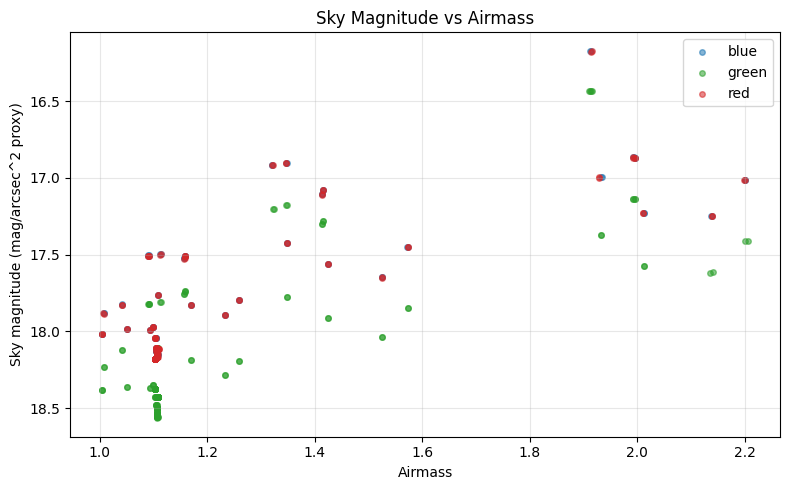

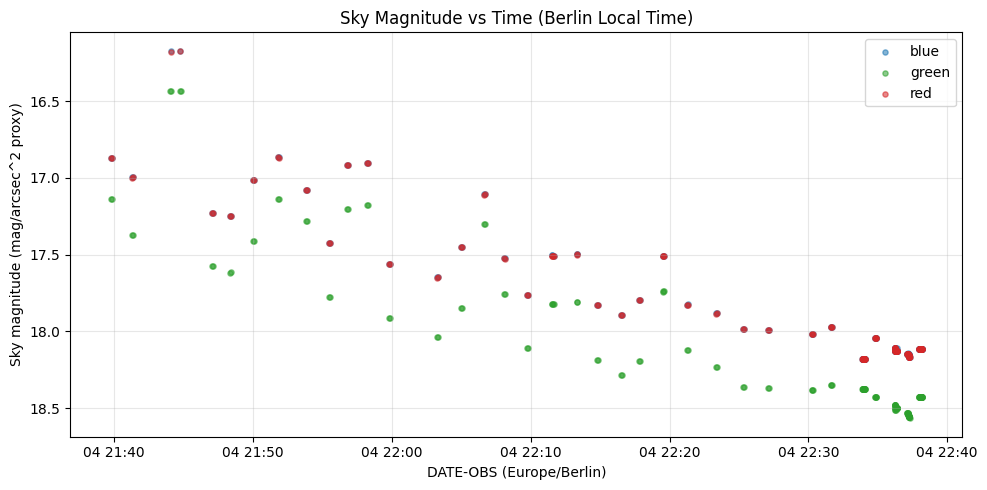

In [42]:
# Sky-magnitude diagnostic plots (Berlin local time for time axis)
if "sky_mag_df" not in globals() or sky_mag_df.empty:
    raise RuntimeError("sky_mag_df is missing or empty. Run the sky-magnitude cell first.")

plot_df = sky_mag_df.copy()

# Ensure numeric columns
for c in ["m_sky", "sigma_m", "gain", "exp_time"]:
    if c in plot_df.columns:
        plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

# Add DATE-OBS and airmass where possible using df_matched linkage
if "df_matched" in globals() and not df_matched.empty:
    aux = df_matched.copy()
    if "full_path" in aux.columns:
        aux["filename"] = aux["full_path"].astype(str).map(lambda p: Path(p).name)

    cols = [c for c in ["filename", "band", "airmass", "full_path"] if c in aux.columns]
    if len(cols) >= 3:
        aux = aux[cols].copy()
        aux["airmass"] = pd.to_numeric(aux.get("airmass", np.nan), errors="coerce")
        aux = aux.dropna(subset=["filename", "band"])

        # per-file representative airmass
        airmass_file = aux.groupby(["filename", "band"], as_index=False)["airmass"].median()
        plot_df = plot_df.merge(airmass_file, on=["filename", "band"], how="left", suffixes=("", "_m"))

        # DATE-OBS extraction from unique files
        if "full_path" in aux.columns:
            path_map = aux.dropna(subset=["full_path"]).drop_duplicates(subset=["filename", "band"])
            date_rows = []
            for row in path_map.itertuples(index=False):
                fpath = Path(row.full_path)
                date_obs = None
                try:
                    with fits.open(fpath) as hdul:
                        date_obs = hdul[0].header.get("DATE-OBS")
                except Exception:
                    pass
                date_rows.append({"filename": row.filename, "band": row.band, "date_obs": date_obs})

            date_df = pd.DataFrame(date_rows)
            if not date_df.empty:
                # Parse as UTC and convert to Berlin local time
                date_df["date_obs_utc"] = pd.to_datetime(date_df["date_obs"], errors="coerce", utc=True)
                date_df["date_obs_berlin"] = date_df["date_obs_utc"].dt.tz_convert("Europe/Berlin")
                plot_df = plot_df.merge(date_df[["filename", "band", "date_obs_berlin"]], on=["filename", "band"], how="left")

# Common style
band_colors = {"blue": "C0", "green": "C2", "red": "C3"}

# 1) m_sky vs airmass
if "airmass" in plot_df.columns and plot_df["airmass"].notna().any():
    plt.figure(figsize=(8, 5))
    for b, c in band_colors.items():
        sel = (plot_df["band"] == b) & np.isfinite(plot_df["airmass"]) & np.isfinite(plot_df["m_sky"])
        if sel.any():
            plt.scatter(plot_df.loc[sel, "airmass"], plot_df.loc[sel, "m_sky"], s=16, alpha=0.55, color=c, label=b)
    plt.gca().invert_yaxis()
    plt.xlabel("Airmass")
    plt.ylabel("Sky magnitude (mag/arcsec^2 proxy)")
    plt.title("Sky Magnitude vs Airmass")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 2) m_sky vs time (Berlin)
if "date_obs_berlin" in plot_df.columns and plot_df["date_obs_berlin"].notna().any():
    plt.figure(figsize=(10, 5))
    for b, c in band_colors.items():
        sel = (plot_df["band"] == b) & plot_df["date_obs_berlin"].notna() & np.isfinite(plot_df["m_sky"])
        if sel.any():
            plt.scatter(plot_df.loc[sel, "date_obs_berlin"], plot_df.loc[sel, "m_sky"], s=14, alpha=0.55, color=c, label=b)
    plt.gca().invert_yaxis()
    plt.xlabel("DATE-OBS (Europe/Berlin)")
    plt.ylabel("Sky magnitude (mag/arcsec^2 proxy)")
    plt.title("Sky Magnitude vs Time (Berlin Local Time)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

